In [14]:
import os
import re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка единого стиля для графиков
sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:.2f}'.format

# Построение базового пути
data_dir = Path('/Users/issturkin/Library/CloudStorage/Dropbox/Обучение/Karpov.Courses/Аналитик данных/Python/Урок 11_Финальный_проект/data')

# Сбор данных по заказам
orders_list = []
for file_path in data_dir.rglob('orders.csv'):
    if file_path.name.startswith(('.', '~')):
        continue
    
    # Чтение файла и обогащение пути
    temp_df = pd.read_csv(file_path)
    temp_df['manager_name'] = file_path.parts[-2]
    temp_df['order_date'] = file_path.parts[-3]
    orders_list.append(temp_df)

df_orders = pd.concat(orders_list, ignore_index=True)\
    .sort_values(['order_id', 'product_id'])

# Сбор данных по статусам заказов
order_status_list = []
for file_path in data_dir.rglob('order_status.csv'):
    if file_path.name.startswith(('.', '~')):
        continue
    temp_df = pd.read_csv(file_path)
    order_status_list.append(temp_df)

df_order_status = pd.concat(order_status_list, ignore_index=True)\
    .sort_values('order_id')

# Сбор данных по продуктам
products_list = []
for file_path in data_dir.rglob('products.csv'):
    if file_path.name.startswith(('.', '~')):
        continue
    temp_df = pd.read_csv(file_path)
    temp_df['category'] = file_path.parts[-2]
    products_list.append(temp_df)

df_products = pd.concat(products_list, ignore_index=True).sort_values('id')

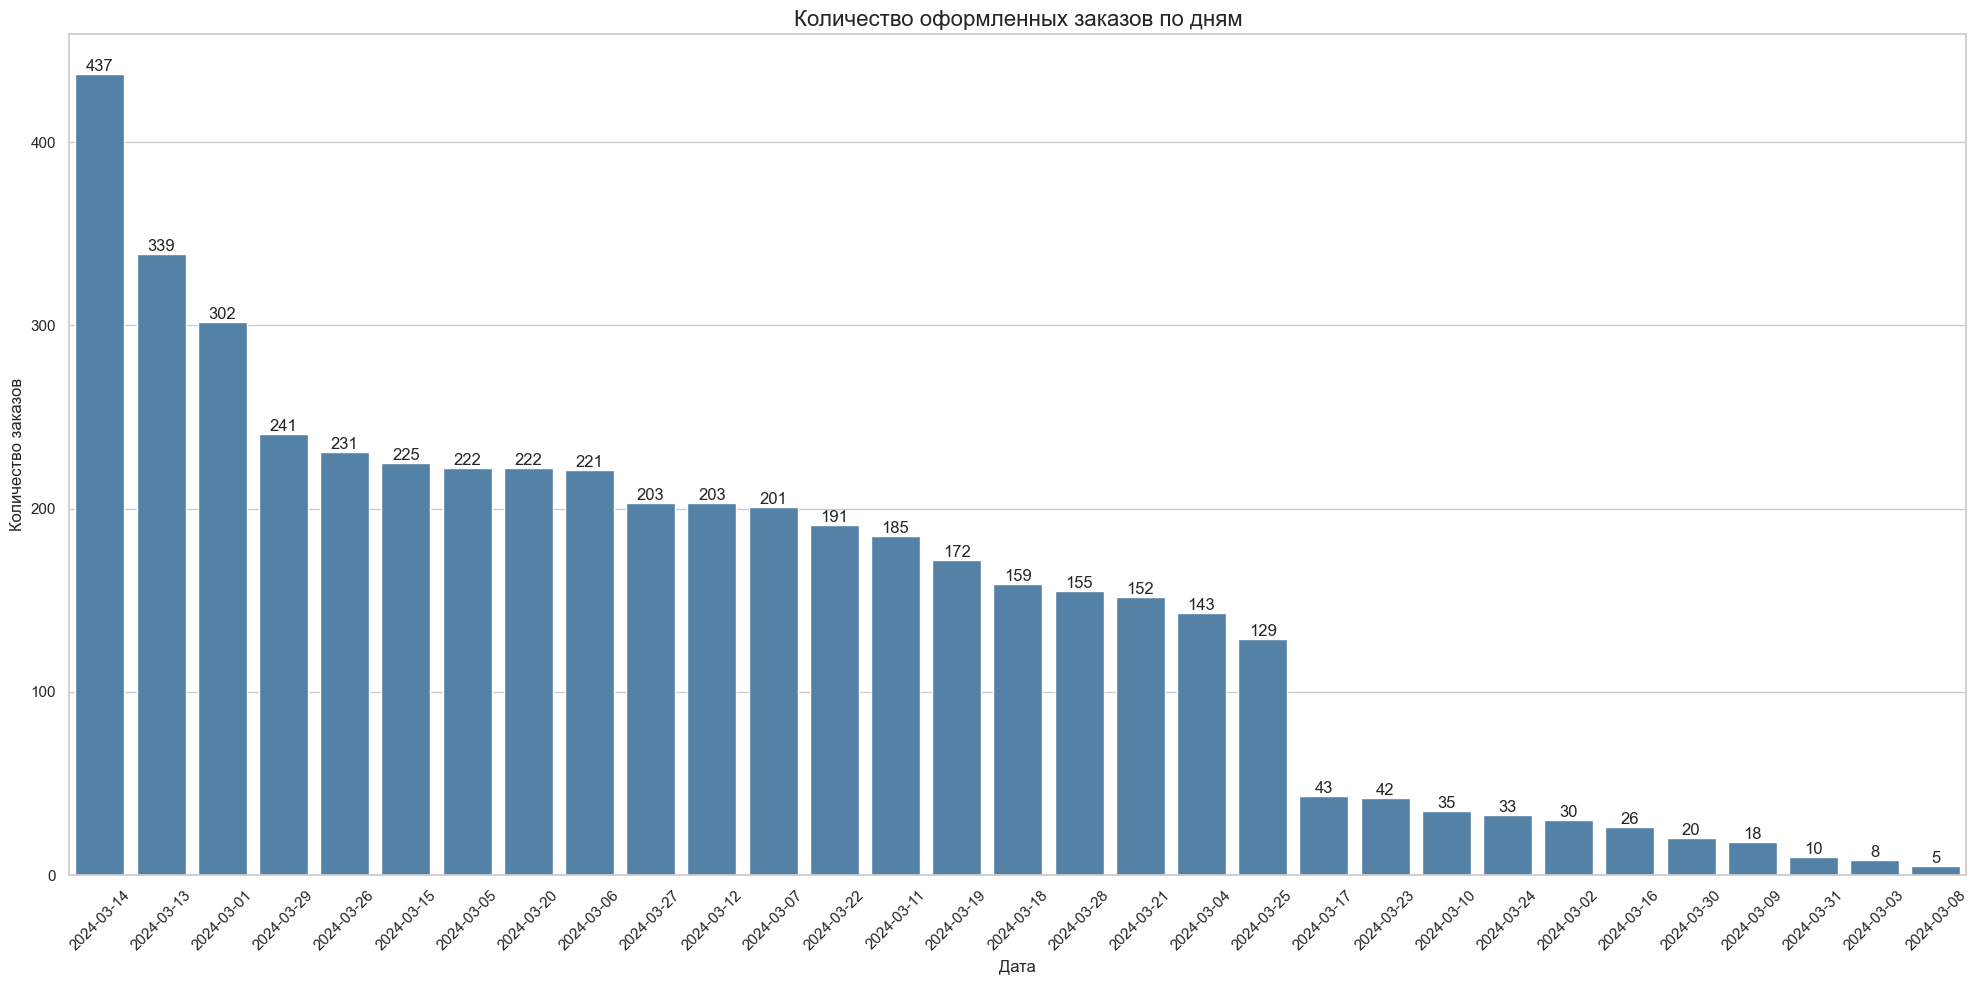

Лучший день: 2024-03-14
Худший день: 2024-03-08 (Friday)


In [15]:
# Приведение дат к формату datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# Подсчет количества заказов по дням
daily_orders_count = df_orders.groupby('order_date', as_index=False)['order_id'].size()
daily_orders_count = daily_orders_count.rename(columns={'size': 'order_count'})\
    .sort_values('order_count', ascending=False)

# Построение графика распределения заказов 
plt.figure(figsize=(20, 10))
ax = sns.barplot(data=daily_orders_count, x=daily_orders_count['order_date']\
    .dt.strftime('%Y-%m-%d'), y='order_count', color='steelblue')

# Добавление подписей данных на столбцы
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)
plt.title('Количество оформленных заказов по дням', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

# Поиск аномальных дней
best_sales_day = daily_orders_count.iloc[0]['order_date'].strftime('%Y-%m-%d')
bad_sales_day = '2024-03-08'
bad_day_name = df_orders.loc[df_orders['order_date'] == bad_sales_day, 'order_date']\
    .dt.day_name().iloc[0]

print(f"Лучший день: {best_sales_day}")
print(f"Худший день: {bad_sales_day} ({bad_day_name})")

Доля статусов:
 status
confirmed   0.89
canceled    0.11
Name: proportion, dtype: float64
День без подтвержденных заказов: 2024-03-09


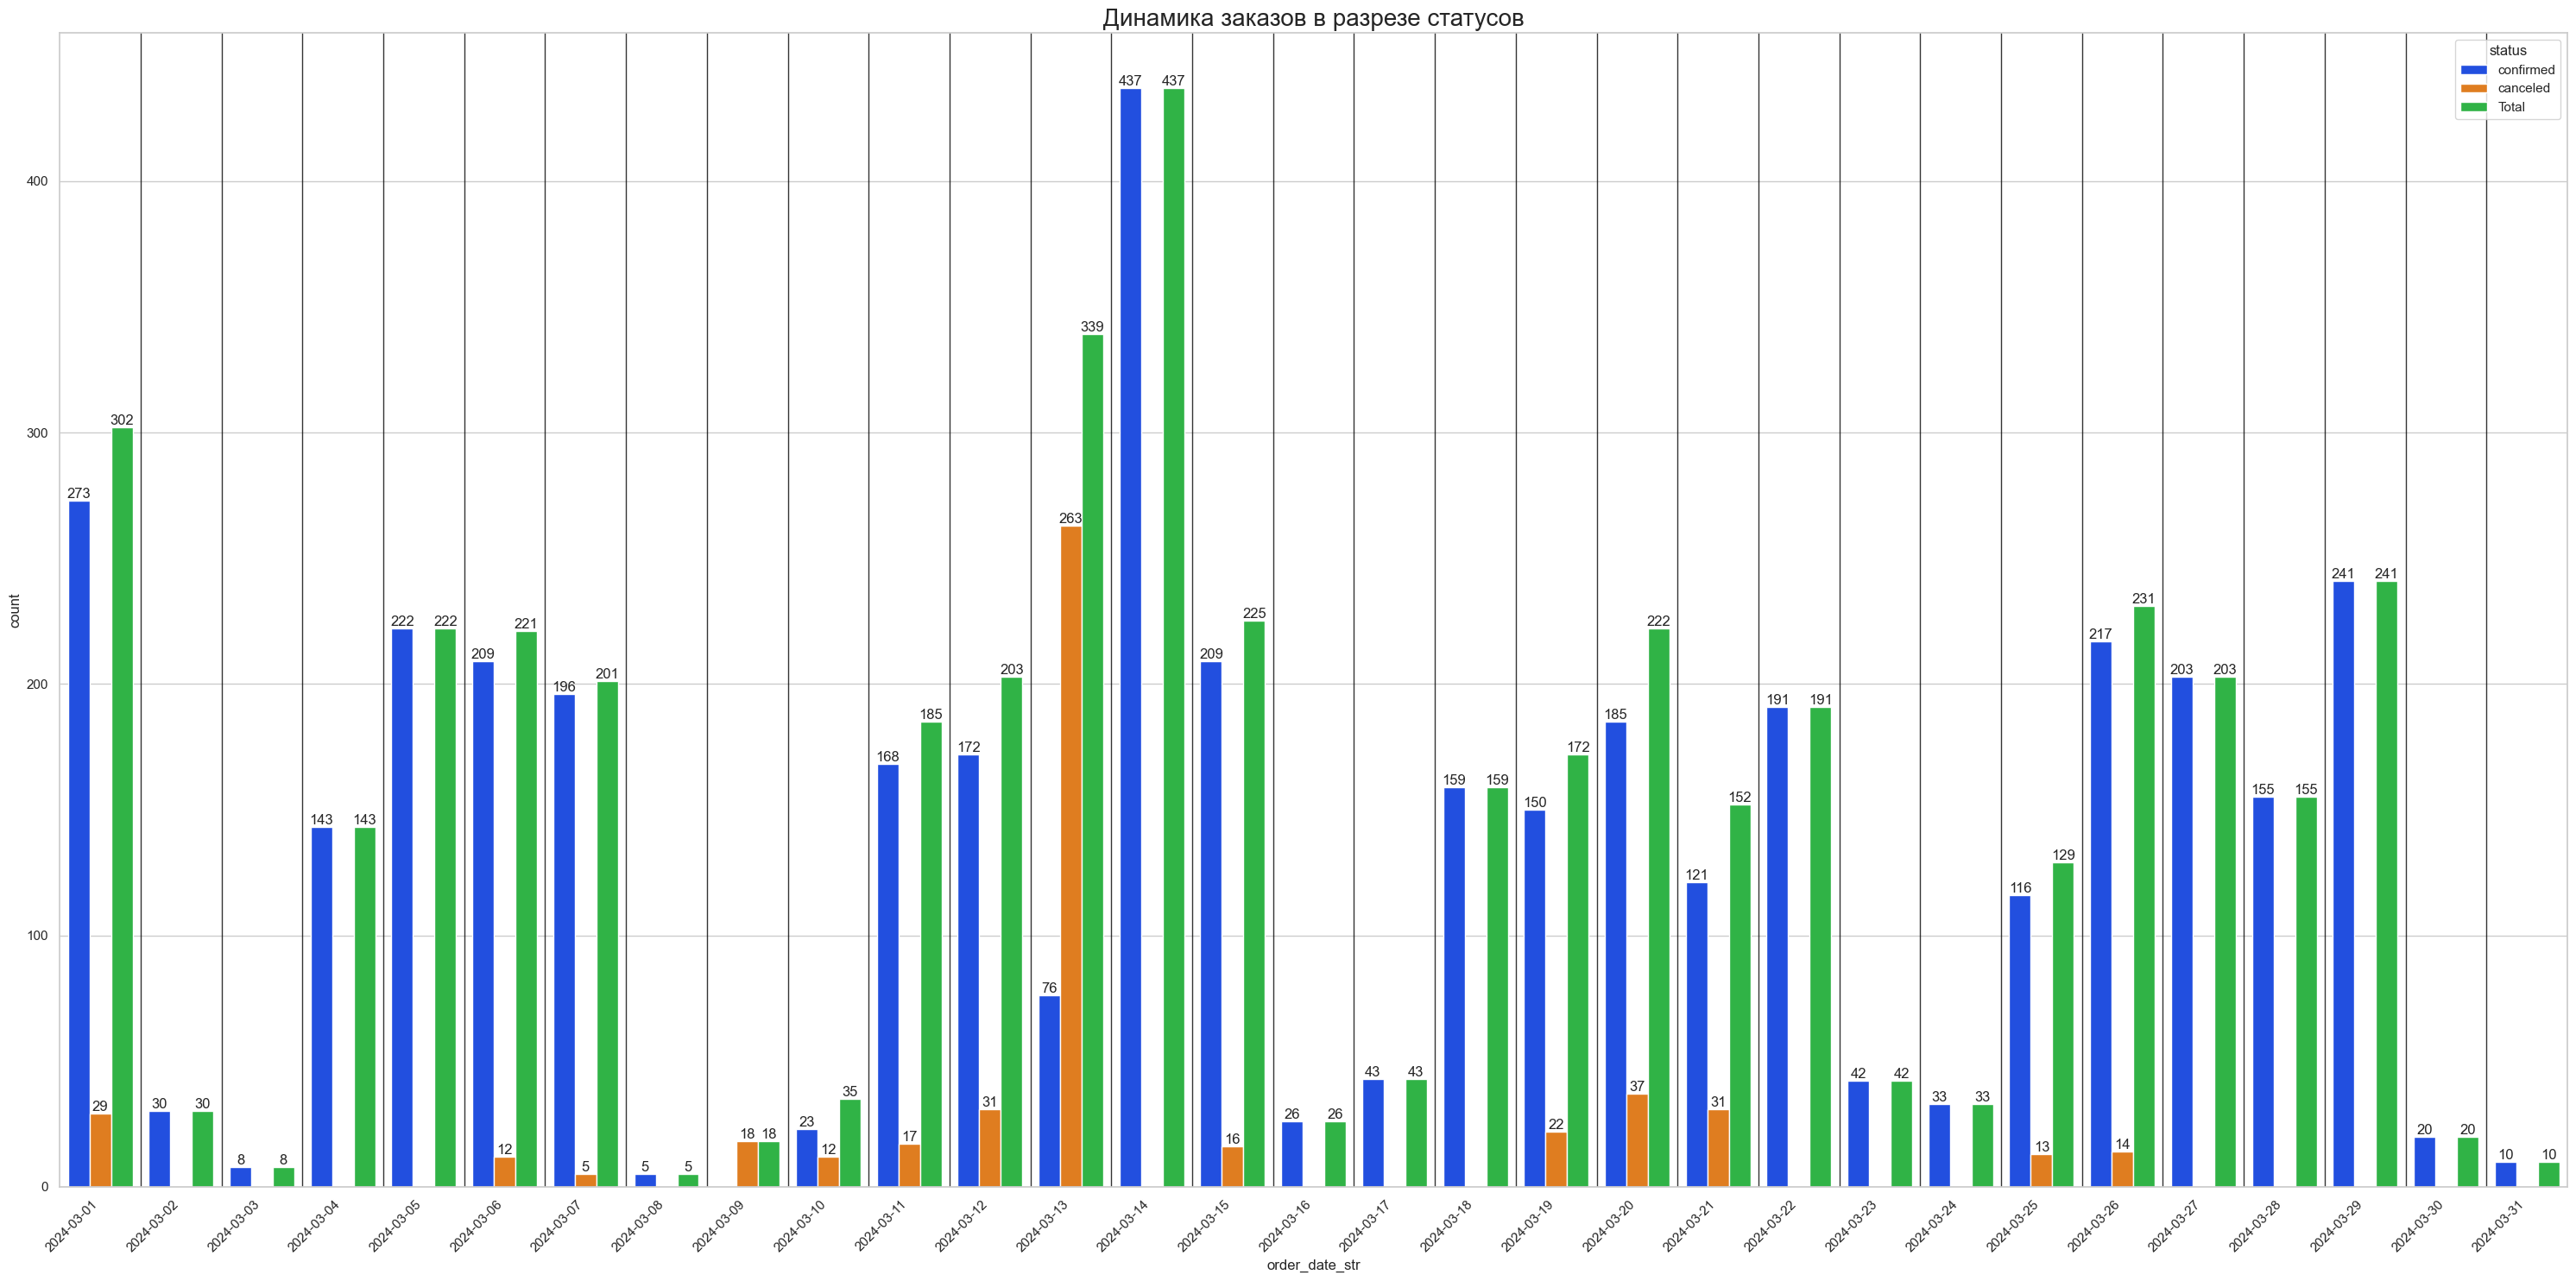

Доля заказов, повторяющих вчерашние: 74.37%


In [16]:
# Объединение заказов со статусами
orders_with_status = df_orders.merge(df_order_status, on='order_id')

orders_with_status.to_csv('orders_status.csv', index=False)

# Расчет долей статусов
status_distribution = orders_with_status['status'].value_counts(normalize=True).round(2)
print("Доля статусов:\n", status_distribution)

# Сводная таблица по статусам в разрезе дней
orders_with_status['order_date'] = pd.to_datetime(orders_with_status['order_date'])

daily_status_pivot = orders_with_status.groupby('order_date', as_index=False)['status'].value_counts() \
    .pivot_table(index='order_date', columns='status', values='count') \
    .reset_index() \
    .fillna(0)

# Поиск дня без подтвержденных заказов
zero_confirmed_day = daily_status_pivot.query('confirmed == 0')['order_date'].iloc[0]
print(f"День без подтвержденных заказов: {zero_confirmed_day.strftime('%Y-%m-%d')}")

# Подготовка данных для мульти-графика статусов 
daily_status_melted = orders_with_status.groupby('order_date', as_index=False)['status'].value_counts()
daily_totals = daily_status_melted.groupby('order_date', as_index=False)['count'].sum()
daily_totals['status'] = 'Total'

combined_status_data = pd.concat([daily_status_melted, daily_totals], ignore_index=True)
combined_status_data['order_date_str'] = combined_status_data['order_date'].dt.strftime('%Y-%m-%d')

plt.figure(figsize=(30, 15))
ax = sns.barplot(data=combined_status_data, x='order_date_str', y='count', hue='status', palette='bright')
plt.xticks(rotation=45, ha='right')

# Отрисовка разделительных линий между днями
for i in range(len(combined_status_data['order_date_str'].unique()) - 1):
    ax.axvline(i + 0.5, color='black', linestyle='-', linewidth=1, alpha=0.8)

for container in ax.containers:
    ax.bar_label(container)
    
plt.title('Динамика заказов в разрезе статусов', fontsize=20)
plt.tight_layout()
plt.show()

# Анализ гипотезы сбоя (дублирование отмененных заказов на следующий день)
target_dates = ['2024-03-13', '2024-03-14']
anomaly_period_df = orders_with_status.loc[orders_with_status['order_date'].dt.strftime('%Y-%m-%d').isin(target_dates)].copy()

# Расчет общего количества товаров в каждом заказе
anomaly_period_df['total_items'] = anomaly_period_df.groupby('order_id')['quantity'].transform('sum')
compare_cols = ['client_id', 'manager_name', 'quantity', 'total_items']

# Разделение на вчерашние и сегодняшние заказы
df_march_13 = anomaly_period_df.loc[anomaly_period_df['order_date'].dt.strftime('%Y-%m-%d') == '2024-03-13']
df_march_14 = anomaly_period_df.loc[anomaly_period_df['order_date'].dt.strftime('%Y-%m-%d') == '2024-03-14']

# Поиск дублей
repeated_orders = df_march_13[compare_cols].merge(df_march_14[compare_cols])

confirmed_14th_count = df_march_14.query('status == "confirmed"')['quantity'].count()
repeat_rate = round((repeated_orders['quantity'].count() / confirmed_14th_count) * 100, 2)
print(f"Доля заказов, повторяющих вчерашние: {repeat_rate}%")

Средний курс доллара за месяц: 91.7
Общая выручка: 2038231821.56 руб.
Средний чек (AOV): 6596219.49 руб.


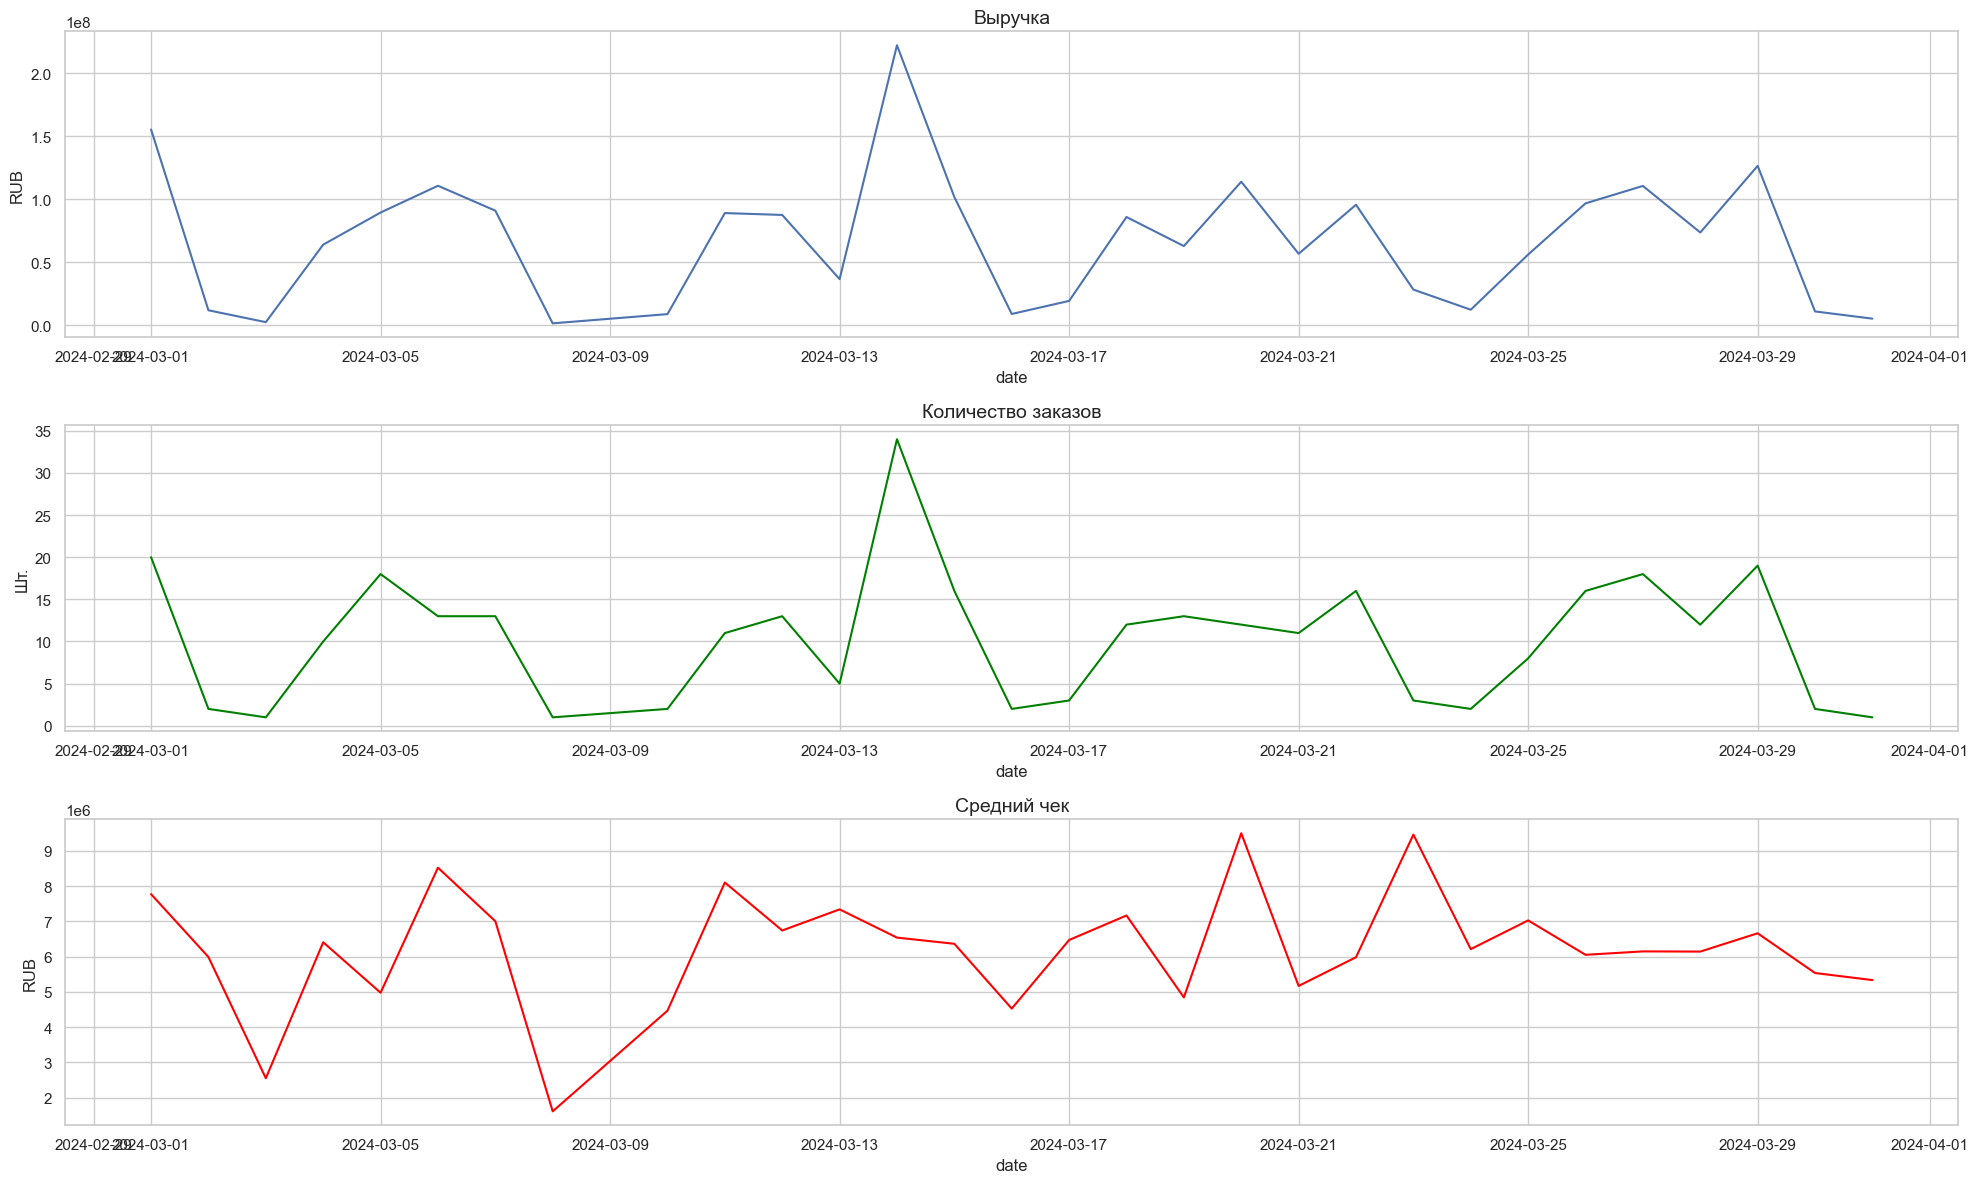

In [17]:
# Загрузка и обработка курсов валют
exchange_rate_path = '/Users/issturkin/Library/CloudStorage/Dropbox/Обучение/Karpov.Courses/Аналитик данных/Python/Урок 11_Финальный_проект/final_project_python/usd_rate.txt'
usd_rate = pd.read_csv(exchange_rate_path, header=None) \
    .rename(columns={0: 'date', 1: 'currency_rate'}) \
    .reset_index()[['date', 'currency_rate']]

usd_rate['date'] = pd.to_datetime(usd_rate['date'])
average_usd_rate = usd_rate['currency_rate'].mean().round(2)
print(f"Средний курс доллара за месяц: {average_usd_rate}")

# Подготовка единого витринного датасета
df_products_renamed = df_products.rename(columns={'id': 'product_id', 'price': 'price_usd'})

orders_with_status = orders_with_status.rename(columns={'order_date': 'date'})

# Сборка финального DataFrame
df_full = orders_with_status.merge(df_products_renamed, on='product_id', how='left') \
    .merge(usd_rate, on='date', how='left')

df_confirmed = df_full.query('status == "confirmed"').copy()

df_confirmed['revenue_rub'] = df_confirmed['quantity'] * df_confirmed['price_usd'] * df_confirmed['currency_rate']

total_revenue = df_confirmed['revenue_rub'].sum().round(2)
average_order_value = round(total_revenue / df_confirmed['order_id'].nunique(), 2)

print(f"Общая выручка: {total_revenue} руб.")
print(f"Средний чек (AOV): {average_order_value} руб.")

# Динамика метрик по дням
daily_metrics = df_confirmed.groupby('date', as_index=False).agg(
    daily_revenue=('revenue_rub', 'sum'),
    unique_orders=('order_id', 'nunique')
)
daily_metrics['daily_aov'] = daily_metrics['daily_revenue'] / daily_metrics['unique_orders']

fig, axes = plt.subplots(3, 1, figsize=(20, 12))

sns.lineplot(data=daily_metrics, x='date', y='daily_revenue', ax=axes[0])
axes[0].set_title('Выручка', fontsize=14)
axes[0].set_ylabel('RUB')

sns.lineplot(data=daily_metrics, x='date', y='unique_orders', ax=axes[1], color='green')
axes[1].set_title('Количество заказов', fontsize=14)
axes[1].set_ylabel('Шт.')

sns.lineplot(data=daily_metrics, x='date', y='daily_aov', ax=axes[2], color='red')
axes[2].set_title('Средний чек', fontsize=14)
axes[2].set_ylabel('RUB')

plt.tight_layout()
plt.show()

In [18]:
# Экстракция названия бренда
brand_pattern = re.compile(r'(\b\w+\b)')
df_confirmed['brand_name'] = df_confirmed['name'].str.extract(brand_pattern)

unique_brands_requested = df_confirmed['brand_name'].nunique()
print(f"Количество уникальных брендов в заказах: {unique_brands_requested}")

# Топ брендов по выручке
top_brands_revenue = df_confirmed.groupby('brand_name', as_index=False).agg(
    total_revenue=('revenue_rub', 'sum'),
    orders_count=('order_id', 'nunique')
).sort_values('total_revenue', ascending=False)

print("Топ-5 брендов по выручке:")
display(top_brands_revenue.head())

# Анализ мертвых остатков на складе (товары без продаж)
ordered_products = df_confirmed['product_id'].unique()

df_products['is_ordered'] = df_products['id'].isin(ordered_products)\
    .replace({True: 'Yes', False: 'No'})
product_usage_stats = df_products['is_ordered']\
    .value_counts(normalize=True) * 100
print("Доля заказанных и незаказанных товаров (%):\n", product_usage_stats)

# Анализ неликвида в разрезе брендов
df_products['brand_name'] = df_products['name'].str.extract(brand_pattern)

all_products_by_brand = df_products.groupby('brand_name', as_index=False)['id']\
    .nunique().rename(columns={'id': 'total_items'})
unsold_products_by_brand = df_products.query('is_ordered == "No"')\
    .groupby('brand_name', as_index=False)['id']\
    .nunique().rename(columns={'id': 'unsold_items'})

liquidity_report = all_products_by_brand\
    .merge(unsold_products_by_brand, on='brand_name', how='left').fillna(0)
liquidity_report['unsold_percentage'] = round((liquidity_report['unsold_items'] / liquidity_report['total_items']) * 100, 2)

illiquid_brands = liquidity_report.query('total_items > 15 and unsold_percentage > 50') \
    .sort_values('unsold_percentage', ascending=False)['brand_name'].tolist()

print("Бренды, требующие внимания закупщиков (>50% неликвида при широком ассортименте):", illiquid_brands)

Количество уникальных брендов в заказах: 121
Топ-5 брендов по выручке:


,brand_name,total_revenue,orders_count
46,JBL,266596053.10,264
43,Heco,238816349.32,229
53,Klipsch,203902418.53,205
120,Yamaha,165865087.71,218
49,KEF,146510060.43,73


Доля заказанных и незаказанных товаров (%):
 is_ordered
Yes   70.36
No    29.64
Name: proportion, dtype: float64
Бренды, требующие внимания закупщиков (>50% неликвида при широком ассортименте): ['Marantz', 'Dali', 'Pioneer', 'KEF']


/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_97786/3971001734.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manager_kpi, x='revenue_share_pct', y='manager_name', palette='plasma', ax=axes[0])
/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_97786/3971001734.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=manager_kpi, x='orders_share_pct', y='manager_name', palette='plasma', ax=axes[1])


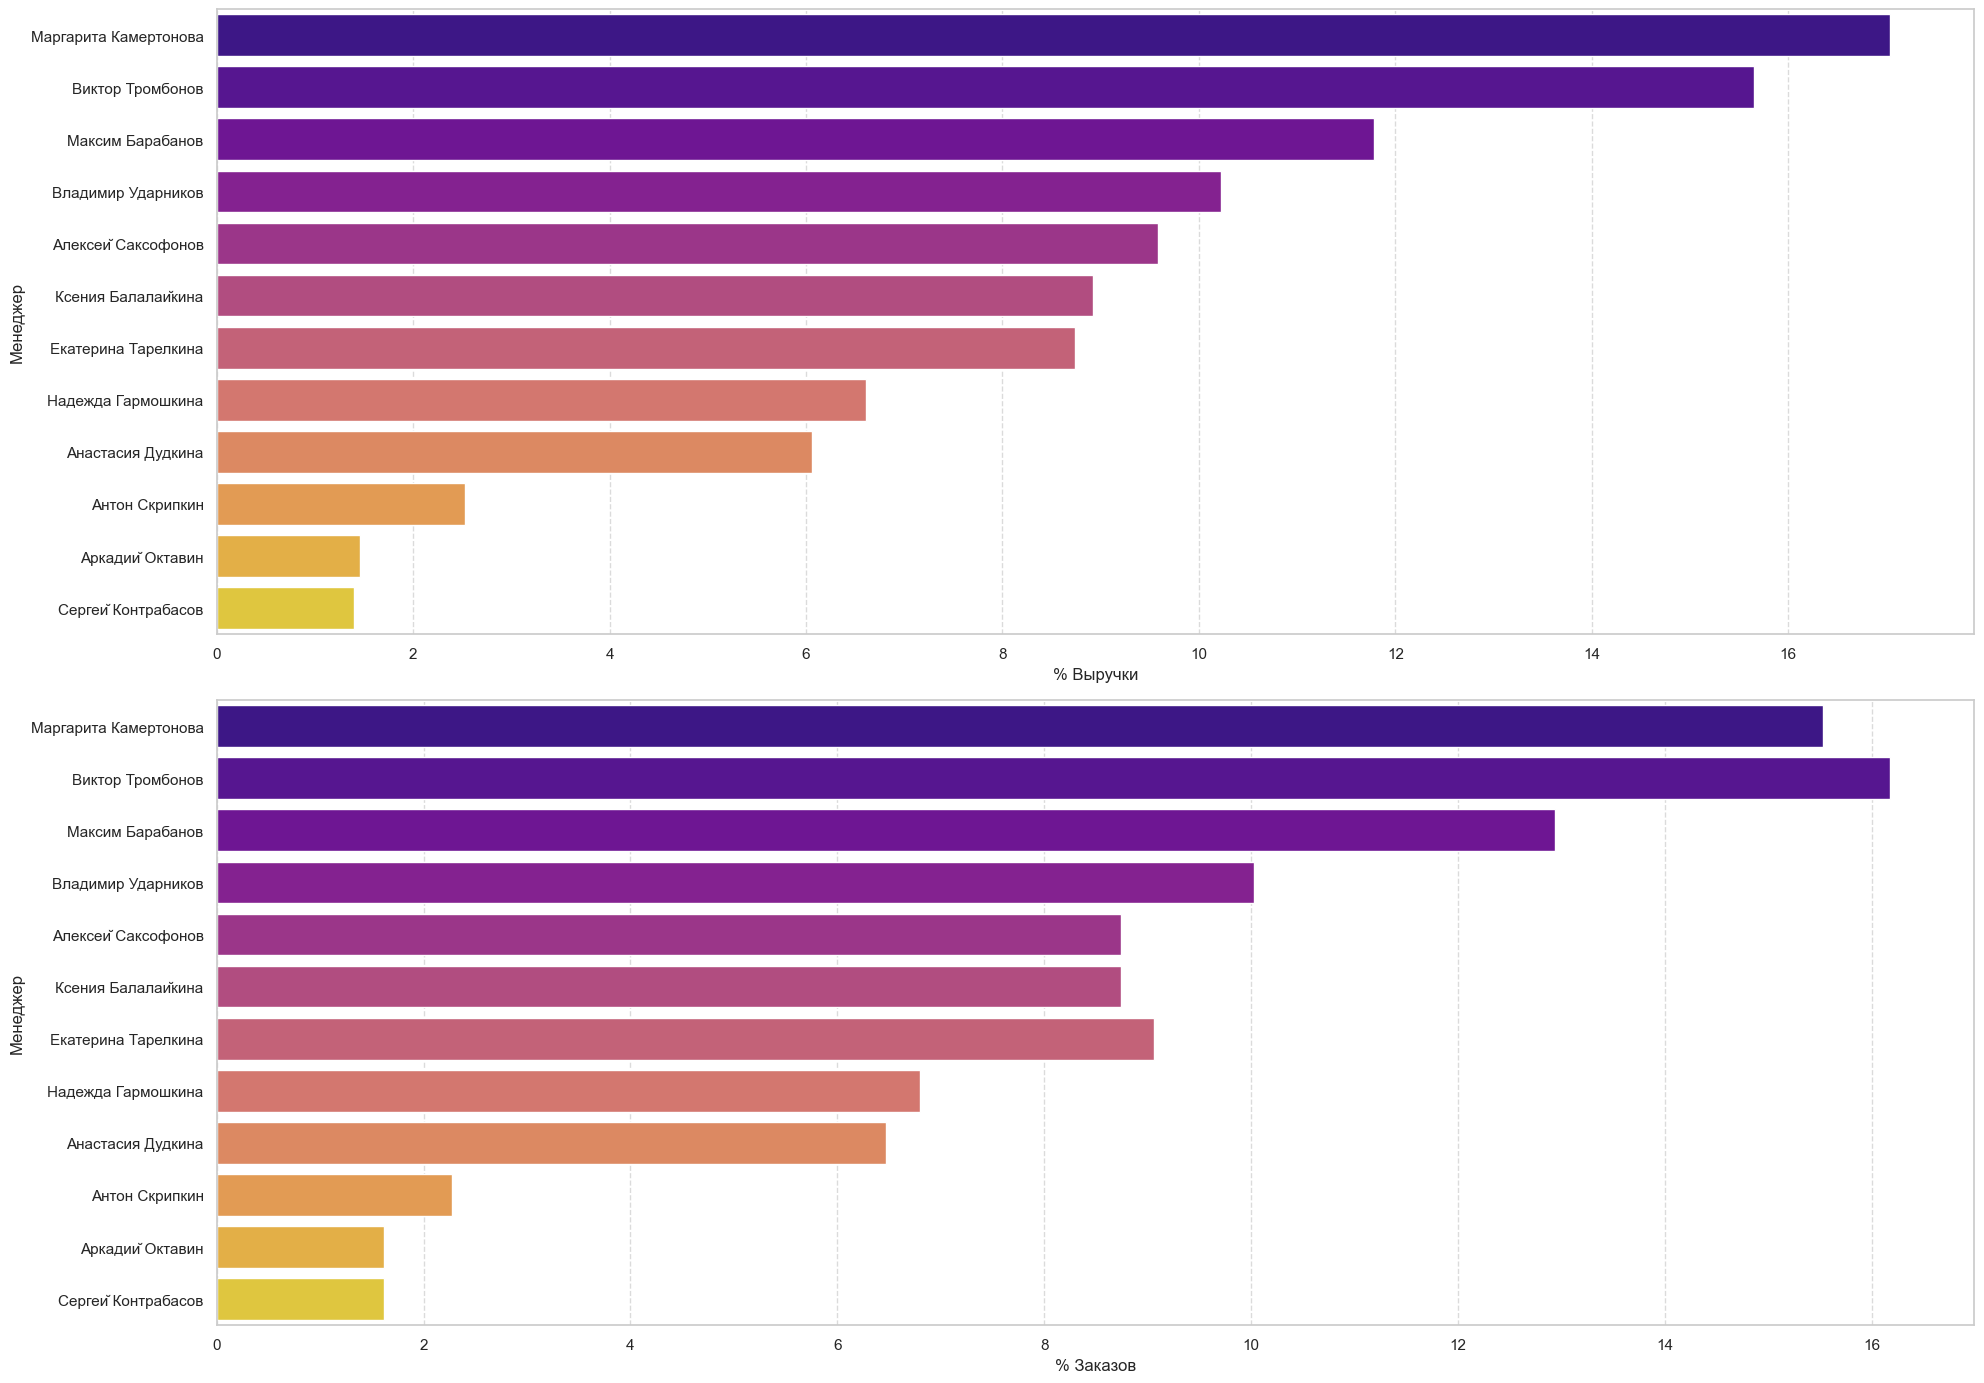

,orders_handled,revenue_generated,orders_share_pct,revenue_share_pct
count,12.00,12.00,12.00,12.00
mean,25.75,169852651.80,8.33,8.33
std,15.35,103577381.66,4.96,5.08
min,5.00,28572232.63,1.62,1.40
25%,16.75,105463442.18,5.42,5.18
50%,27.00,179959888.26,8.74,8.83
75%,33.25,216401815.01,10.76,10.62
max,50.00,347388593.11,16.18,17.04


In [19]:
# Агрегация успехов менеджеров
total_confirmed_orders = df_confirmed['order_id'].nunique()

manager_kpi = df_confirmed.groupby('manager_name', as_index=False).agg(
    orders_handled=('order_id', 'nunique'),
    revenue_generated=('revenue_rub', 'sum')
)

# Перевод в проценты
manager_kpi['orders_share_pct'] = round((manager_kpi['orders_handled'] / total_confirmed_orders) * 100, 2)
manager_kpi['revenue_share_pct'] = round((manager_kpi['revenue_generated'] / total_revenue) * 100, 2)
manager_kpi = manager_kpi.sort_values(['revenue_share_pct', 'orders_share_pct'], ascending=False)

# Визуализация KPI (соответствует твоему 4.png)
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

sns.barplot(data=manager_kpi, x='revenue_share_pct', y='manager_name', palette='plasma', ax=axes[0])
axes[0].set_xlabel('% Выручки')
axes[0].set_ylabel('Менеджер')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(data=manager_kpi, x='orders_share_pct', y='manager_name', palette='plasma', ax=axes[1])
axes[1].set_xlabel('% Заказов')
axes[1].set_ylabel('Менеджер')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

display(manager_kpi.describe())

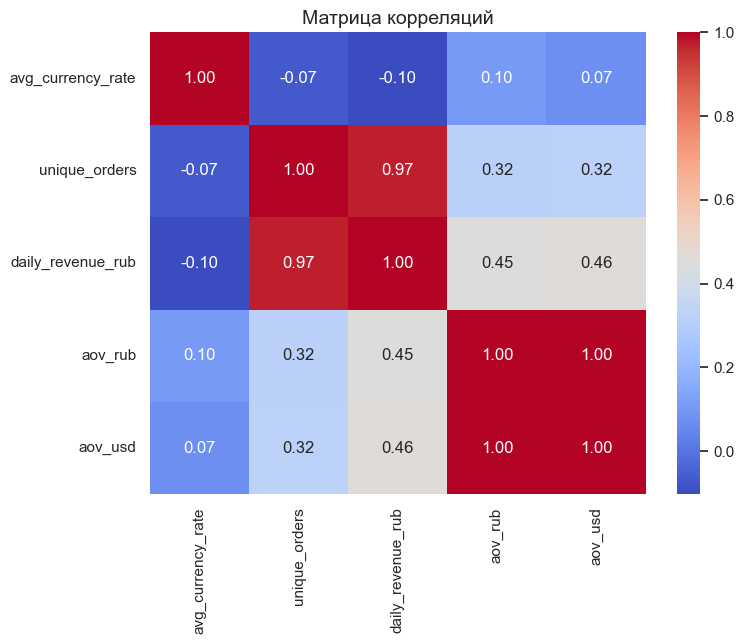

Топ брендов при ДОРОГОМ долларе:
 brand_name
JBL        285
Heco       191
Yamaha     172
Klipsch    141
Magnat      94
Name: count, dtype: int64


/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_97786/3484845714.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lost_revenue_by_brand, x='brand_name', y='lost_revenue_rub', palette='plasma')


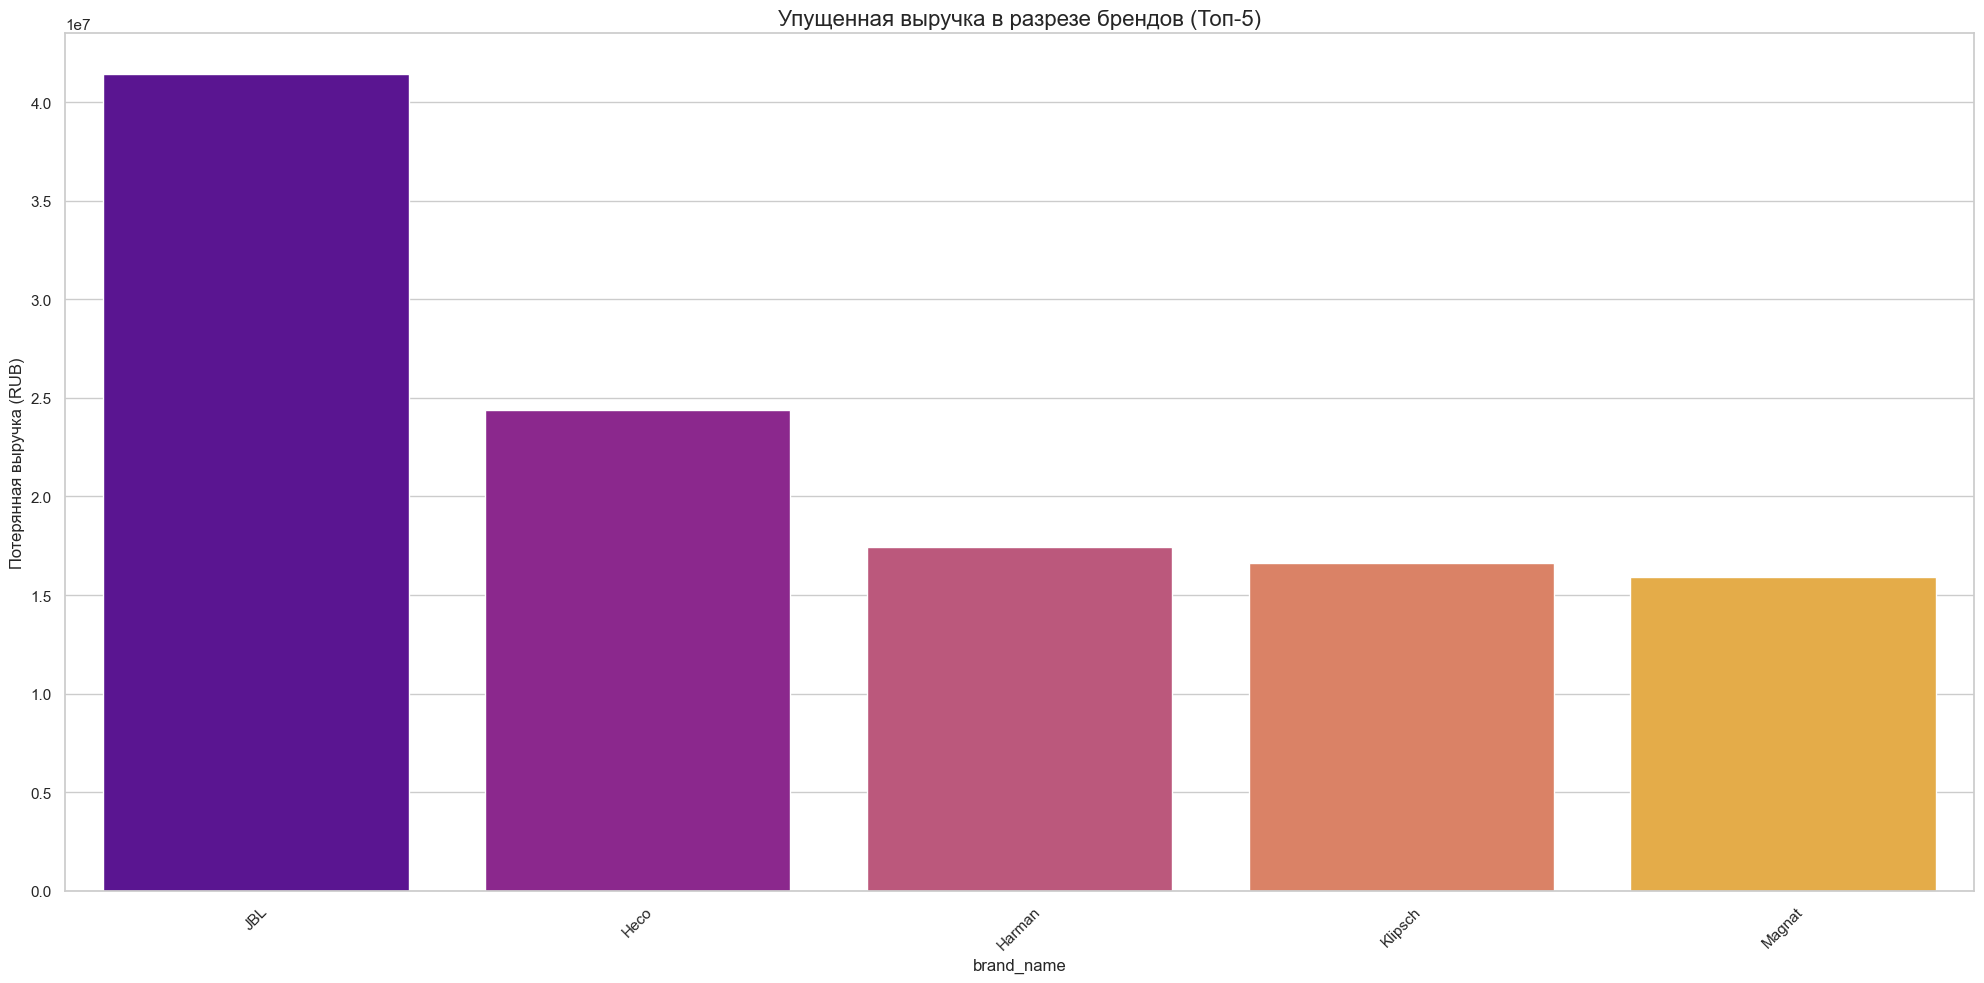

In [20]:


# Поиск корреляции: Курс доллара vs. Активность покупателей (соответствует твоему 5.png)

df_full['revenue_rub'] = df_full['quantity'] * df_full['price_usd'] * df_full['currency_rate']

brand_pattern = re.compile(r'(\b\w+\b)')
df_full['brand_name'] = df_full['name'].str.extract(brand_pattern)

# Агрегация данных по дням
correlation_df = df_full.groupby('date', as_index=False).agg(
    avg_currency_rate=('currency_rate', 'mean'),
    unique_orders=('order_id', 'nunique'),
    daily_revenue_rub=('revenue_rub', 'sum') 
)

correlation_df['aov_rub'] = correlation_df['daily_revenue_rub'] / correlation_df['unique_orders']
correlation_df['aov_usd'] = correlation_df['aov_rub'] / correlation_df['avg_currency_rate']

# Матрица корреляций
corr_matrix = correlation_df[['avg_currency_rate', 'unique_orders', 'daily_revenue_rub', 'aov_rub', 'aov_usd']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций', fontsize=14)
plt.show()

# Анализ смещения спроса (Downgrade effect)
# Обновляем df_confirmed с учетом новых колонок из df_full
df_confirmed = df_full.query('status == "confirmed"').copy()

df_confirmed['rate_category'] = pd.cut(
    df_confirmed['currency_rate'], 
    bins=[0, df_confirmed['currency_rate'].mean(), np.inf], 
    labels=['Дешевый доллар', 'Дорогой доллар']
)

# Сравнение спроса
cheap_dollar_brands = df_confirmed.query('rate_category == "Дешевый доллар"')['brand_name'].value_counts().head()
expensive_dollar_brands = df_confirmed.query('rate_category == "Дорогой доллар"')['brand_name'].value_counts().head()

print("Топ брендов при ДОРОГОМ долларе:\n", expensive_dollar_brands)

# Оценка упущенной выгоды из-за отмен 
df_canceled = df_full.query('status == "canceled"').copy()

# Высчитываем потерянную выручку
df_canceled['lost_revenue_rub'] = df_canceled['quantity'] * df_canceled['price_usd'] * df_canceled['currency_rate']

lost_revenue_by_brand = df_canceled.groupby('brand_name', as_index=False)['lost_revenue_rub'] \
    .sum().sort_values('lost_revenue_rub', ascending=False).head()

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=lost_revenue_by_brand, x='brand_name', y='lost_revenue_rub', palette='plasma')
plt.xticks(rotation=45)
plt.title('Упущенная выручка в разрезе брендов (Топ-5)', fontsize=16)
plt.ylabel('Потерянная выручка (RUB)')
plt.tight_layout()
plt.show()